# AI3003 Lab2：CNN 识别 Fashion-MNIST

## 数据加载与实验准备


In [3]:
# 设置随机种子，并选择计算设备（GPU、MPS 或 CPU）

import os
import random
import sys
from pathlib import Path

import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
    
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

ROOT = Path.cwd()
if not (ROOT / "cnn.py").exists():
    ROOT = ROOT / "lab" / "lab2"

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Using device: {device}")
print(f"Working directory: {ROOT.resolve()}")

Using device: cuda
Working directory: /workspace


In [4]:
# 加载数据集并进行预处理，划分训练集、验证集和测试集

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

full_train = datasets.FashionMNIST(
    root=ROOT / "data",
    train=True,
    download=True,
    transform=transform,
)
full_test = datasets.FashionMNIST(
    root=ROOT / "data",
    train=False,
    download=True,
    transform=transform,
)

train_size = int(len(full_train) * 5 / 6) # 训练集 50000 张，验证集 10000 张
val_size = len(full_train) - train_size
split_generator = torch.Generator().manual_seed(seed)
train_set, val_set = random_split(full_train, [train_size, val_size], generator=split_generator)

BATCH_SIZE = 512
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True,
    multiprocessing_context="spawn",
    persistent_workers=True,
)
val_loader = DataLoader(
    val_set, batch_size=BATCH_SIZE,
    num_workers=4, pin_memory=True,
    multiprocessing_context="spawn",
    persistent_workers=True,
)
test_loader = DataLoader(
    full_test, batch_size=BATCH_SIZE,
    num_workers=4, pin_memory=True,
    multiprocessing_context="spawn",
    persistent_workers=True,
)

class_names = full_train.classes
mean = torch.tensor(0.2860)
std = torch.tensor(0.3530)

print(f"训练集大小: {len(train_set)}")
print(f"验证集大小: {len(val_set)}")
print(f"测试集大小: {len(full_test)}")
print(f"类别: {class_names}")


训练集大小: 50000
验证集大小: 10000
测试集大小: 10000
类别: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


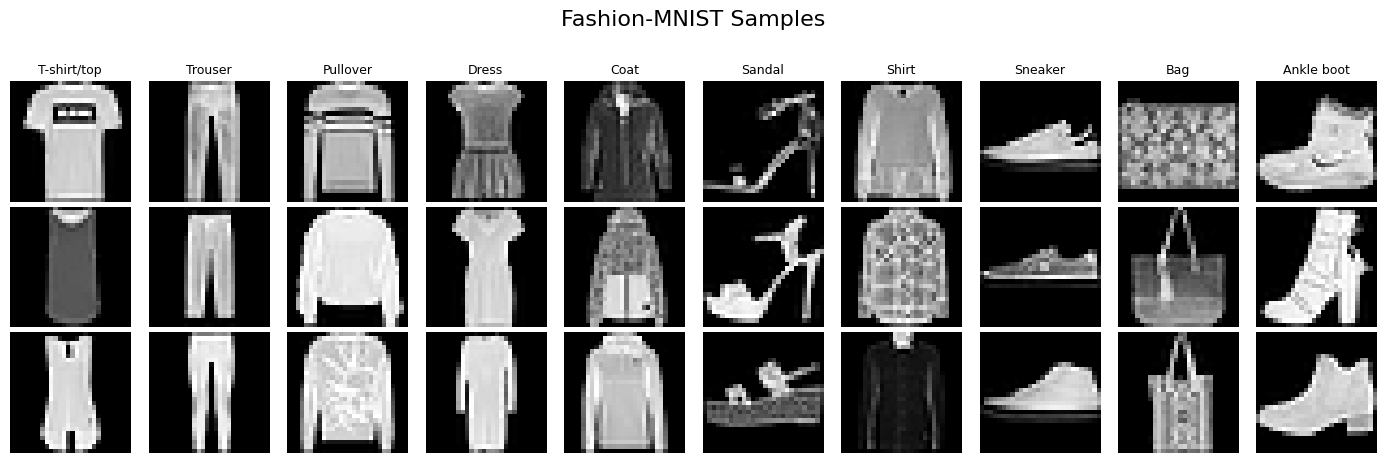

In [5]:
# 打印示例

import matplotlib.pyplot as plt

samples_per_class = 3
class_samples = {i: [] for i in range(len(class_names))}

for image, label in full_train:
    if len(class_samples[label]) < samples_per_class:
        class_samples[label].append(image)
    if all(len(images) == samples_per_class for images in class_samples.values()):
        break

fig, axes = plt.subplots(samples_per_class, len(class_names), figsize=(14, 4.5))
fig.suptitle("Fashion-MNIST Samples", fontsize=16, y=1.02)

for row in range(samples_per_class):
    for col, class_name in enumerate(class_names):
        ax = axes[row, col]
        image = class_samples[col][row] * std + mean
        ax.imshow(image.squeeze(), cmap="gray")
        ax.axis("off")
        if row == 0:
            ax.set_title(class_name, fontsize=9)

plt.tight_layout()
plt.show()


## 对比实验

下面按实验内容分段组织 notebook：先做网络深度对比，再做卷积核大小、池化方式以及 Batch Normalization / Dropout 的消融分析，最后进行测试集评估与错误分析。


In [6]:
# 对比实验共用的依赖与超参数

import pandas as pd
from IPython.display import display

from cnn import CNN, evaluate_model, train_model as fit_model

EPOCHS = 100
LR = 1e-3
criterion = torch.nn.CrossEntropyLoss()


### 1. 网络深度的影响


In [7]:
def train_model(name, num_epochs=EPOCHS, lr=LR, **model_kwargs):
    model = CNN(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = fit_model(
        model=model,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        num_epochs=num_epochs,
        device=device,
        show_progress=True,
    )
    return {
        "name": name,
        "model": model,
        "config": model_kwargs,
        "lr": lr,
        "num_epochs": num_epochs,
        "params": sum(p.numel() for p in model.parameters()),
        **history,
    }


In [8]:
def summary_table(results):
    rows = []
    for name, result in results.items():
        rows.append({
            "模型": name,
            "参数量": result["params"],
            "最佳 epoch": result["best_epoch"],
            "最佳验证准确率": round(result["best_val_accuracy"], 4),
            "最佳验证损失": round(result["best_val_loss"], 4),
        })
    df = pd.DataFrame(rows).sort_values("最佳验证准确率", ascending=False).reset_index(drop=True)
    display(df)
    return df


In [9]:
depth_results = {
    "2 Conv Layers": train_model(
        "2 Conv Layers",
        hidden_layers=2,
        hidden_channels=[32, 64],
        apply_pooling=[True, True],
        kernel_size=3,
        pooling_strategy="avg",
        use_batch_norm=True,
        dropout=0.1,
    ),
    "3 Conv Layers": train_model(
        "3 Conv Layers",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=3,
        pooling_strategy="avg",
        use_batch_norm=True,
        dropout=0.1,
    ),
    "4 Conv Layers": train_model(
        "4 Conv Layers",
        hidden_layers=4,
        hidden_channels=[32, 64, 128, 128],
        apply_pooling=[True, True, False, False],
        kernel_size=3,
        pooling_strategy="avg",
        use_batch_norm=True,
        dropout=0.1,
    ),
}

# 打印各模型的参数量
for name, result in depth_results.items():
    print(f"{name} 参数量: {result['params']}")

depth_table = summary_table(depth_results)


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Batch 1/100:   0%|          | 0/98 [00:07<?, ?it/s]

Batch 2/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 3/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 4/100:   0%|          | 0/98 [00:00<?, ?it/s]

...

Batch 98/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 99/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 100/100:   0%|          | 0/98 [00:00<?, ?it/s]

2 Conv Layers 参数量: 50378
3 Conv Layers 参数量: 155850
4 Conv Layers 参数量: 303690


,模型,参数量,最佳 epoch,最佳验证准确率,最佳验证损失
0,4 Conv Layers,303690,85,0.9346,0.3384
1,3 Conv Layers,155850,43,0.9331,0.2310
2,2 Conv Layers,50378,76,0.9307,0.2178


In [10]:
def plot_validation_curves(results, title, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, result in results.items():
        epochs = range(1, len(result["val_accuracies"]) + 1)
        axes[0].plot(epochs, result["val_accuracies"], marker="o", label=name)
        axes[1].plot(epochs, result["val_losses"], marker="o", label=name)

    axes[0].set_title(f"{title}: Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title(f"{title}: Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()


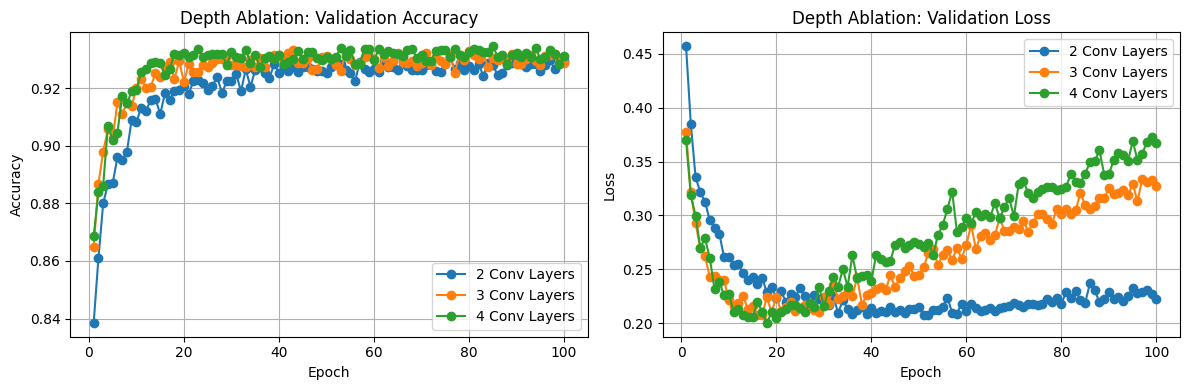

In [11]:
plot_validation_curves(depth_results, "Depth Ablation", save_name="depth_ablation.png")


### 2. 卷积核大小的影响


In [12]:
baseline_result = depth_results["3 Conv Layers"]

kernel_results = {
    "3x3": baseline_result,
    "5x5": train_model(
        "5x5",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=5,
        pooling_strategy="avg",
        use_batch_norm=True,
        dropout=0.1,
    ),
    "7x7": train_model(
        "7x7",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=7,
        pooling_strategy="avg",
        use_batch_norm=True,
        dropout=0.1,
    ),
}

# 打印各模型的参数量
for name, result in kernel_results.items():
    print(f"{name} 参数量: {result['params']}")

kernel_table = summary_table(kernel_results)


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Batch 1/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 2/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 3/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 4/100:   0%|          | 0/98 [00:00<?, ?it/s]

...

Batch 98/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 99/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 100/100:   0%|          | 0/98 [00:00<?, ?it/s]

3x3 参数量: 155850
5x5 参数量: 320202
7x7 参数量: 566730


,模型,参数量,最佳 epoch,最佳验证准确率,最佳验证损失
0,3x3,155850,43,0.9331,0.2310
1,5x5,320202,37,0.9291,0.2639
2,7x7,566730,85,0.9267,0.4155


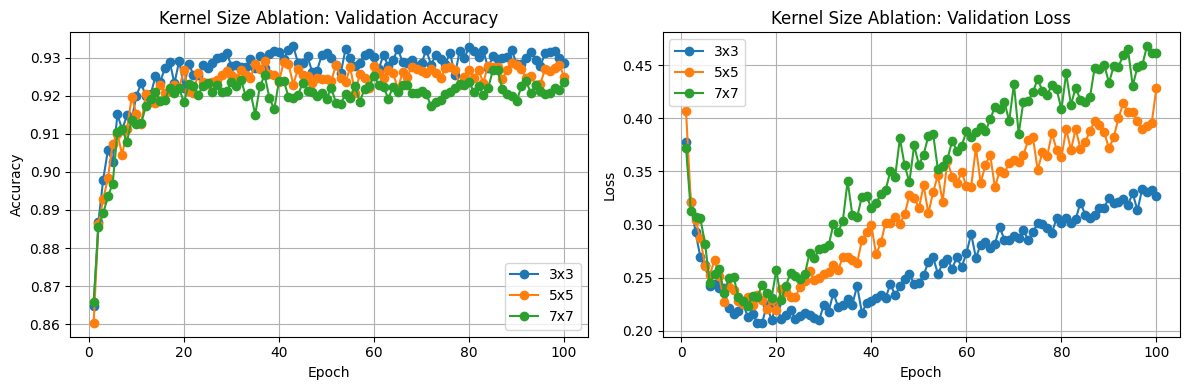

In [13]:
plot_validation_curves(kernel_results, "Kernel Size Ablation", save_name="kernel_ablation.png")


### 3. 池化方式的影响


In [14]:
pooling_results = {
    "Average Pooling": baseline_result,
    "Max Pooling": train_model(
        "Max Pooling",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=3,
        pooling_strategy="max",
        use_batch_norm=True,
        dropout=0.1,
    ),
}

# 打印各模型的参数量
for name, result in pooling_results.items():
    print(f"{name} 参数量: {result['params']}")

pooling_table = summary_table(pooling_results)


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Batch 1/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 2/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 3/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 4/100:   0%|          | 0/98 [00:00<?, ?it/s]

...

Batch 98/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 99/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 100/100:   0%|          | 0/98 [00:00<?, ?it/s]

Average Pooling 参数量: 155850
Max Pooling 参数量: 155850


,模型,参数量,最佳 epoch,最佳验证准确率,最佳验证损失
0,Average Pooling,155850,43,0.9331,0.231
1,Max Pooling,155850,99,0.9266,0.366


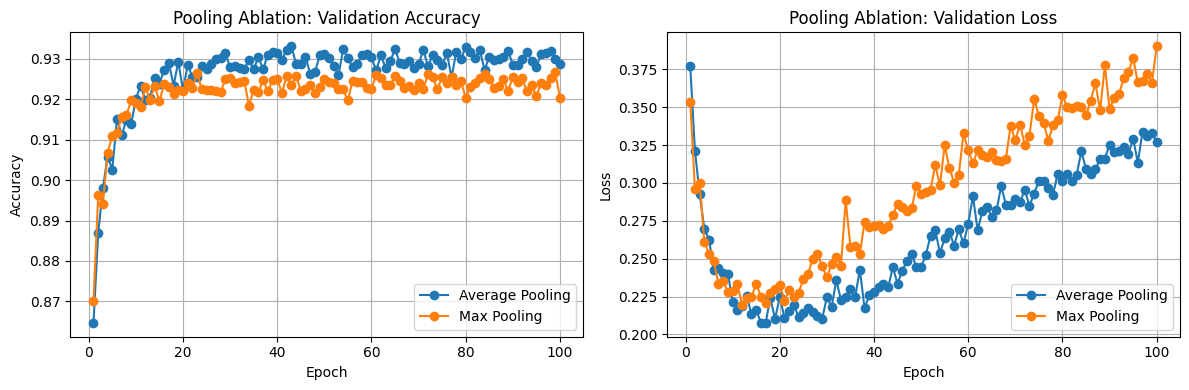

In [15]:
plot_validation_curves(pooling_results, "Pooling Ablation", save_name="pooling_ablation.png")


### 4. Batch Normalization 和 Dropout 的影响


In [16]:
regularization_results = {
    "Baseline": baseline_result,
    "No BatchNorm": train_model(
        "No BatchNorm",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=3,
        pooling_strategy="avg",
        use_batch_norm=False,
        dropout=0.1,
    ),
    "No Dropout": train_model(
        "No Dropout",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=3,
        pooling_strategy="avg",
        use_batch_norm=True,
        dropout=0.0,
    ),
    "No BatchNorm or Dropout": train_model(
        "No BatchNorm or Dropout",
        hidden_layers=3,
        hidden_channels=[32, 64, 128],
        apply_pooling=[True, True, False],
        kernel_size=3,
        pooling_strategy="avg",
        use_batch_norm=False,
        dropout=0.0,
    ),
}

# 打印各模型的参数量
for name, result in regularization_results.items():
    print(f"{name} 参数量: {result['params']}")

regularization_table = summary_table(regularization_results)


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Batch 1/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 2/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 3/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 4/100:   0%|          | 0/98 [00:00<?, ?it/s]

...

Batch 98/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 99/100:   0%|          | 0/98 [00:00<?, ?it/s]

Batch 100/100:   0%|          | 0/98 [00:00<?, ?it/s]

Baseline 参数量: 155850
No BatchNorm 参数量: 155402
No Dropout 参数量: 155850
No BatchNorm or Dropout 参数量: 155402


,模型,参数量,最佳 epoch,最佳验证准确率,最佳验证损失
0,Baseline,155850,43,0.9331,0.2310
1,No BatchNorm,155402,89,0.9288,0.3288
2,No Dropout,155850,88,0.9287,0.4410
3,No BatchNorm or Dropout,155402,95,0.9272,0.5726


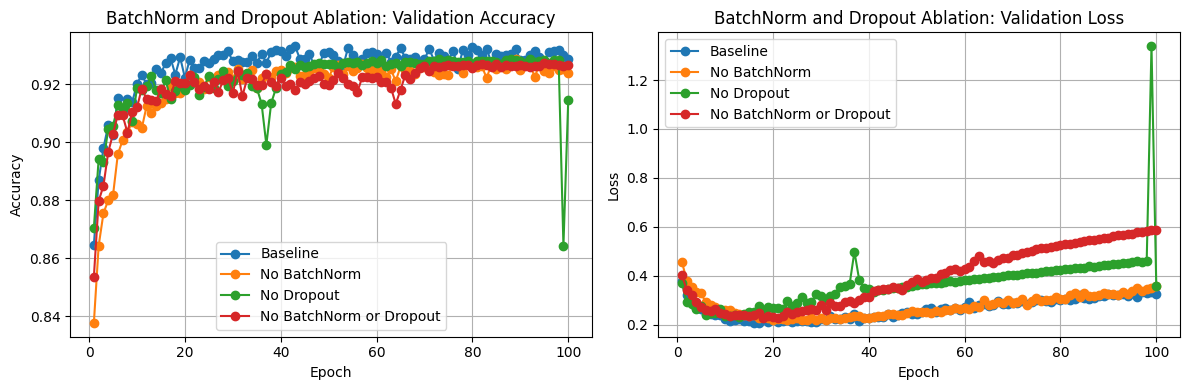

In [17]:
plot_validation_curves(regularization_results, "BatchNorm and Dropout Ablation", save_name="regularization_ablation.png")


In [21]:
def plot_training_curves(results, title, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, result in results.items():
        epochs = range(1, len(result["train_accuracies"]) + 1)
        axes[0].plot(epochs, result["train_accuracies"], marker="o", label=name)
        axes[1].plot(epochs, result["train_losses"], marker="o", label=name)

    axes[0].set_title(f"{title}: Training Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title(f"{title}: Training Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()


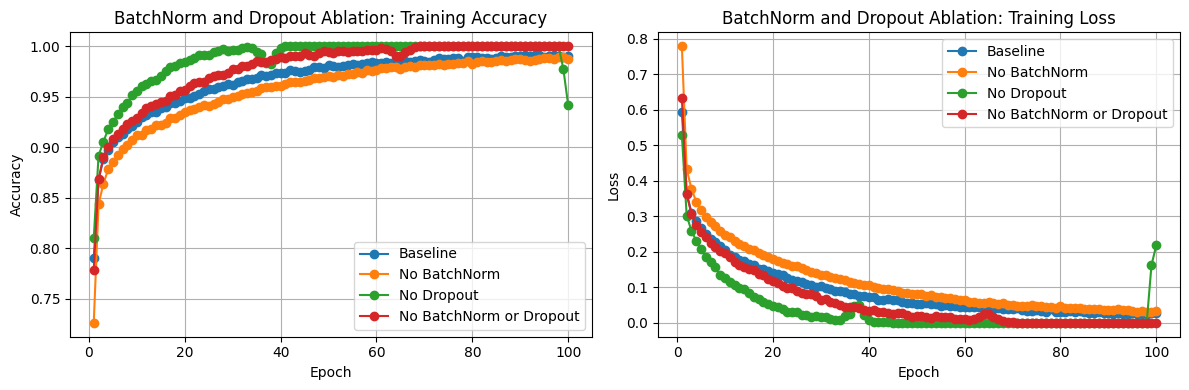

In [22]:
plot_training_curves(regularization_results, "BatchNorm and Dropout Ablation", save_name="regularization_ablation_train.png")


In [30]:
first_one_of_no_dropout = np.argmax(regularization_results["No Dropout"]["train_accuracies"])
first_one_of_no_both = np.argmax(regularization_results["No BatchNorm or Dropout"]["train_accuracies"])
print(f"First train_acc = 1.0 of No Dropout occurs on epoch={first_one_of_no_dropout}")
print(f"First train_acc = 1.0 of No Both occurs on epoch={first_one_of_no_both}")

First train_acc = 1.0 of No Dropout occurs on epoch=41
First train_acc = 1.0 of No Both occurs on epoch=70


In [18]:
all_results = {
    "2 Conv Layers": depth_results["2 Conv Layers"],
    "3 Conv Layers": baseline_result,
    "4 Conv Layers": depth_results["4 Conv Layers"],
    "5x5": kernel_results["5x5"],
    "7x7": kernel_results["7x7"],
    "Average Pooling": pooling_results["Average Pooling"],
    "No BatchNorm": regularization_results["No BatchNorm"],
    "No Dropout": regularization_results["No Dropout"],
    "No BatchNorm or Dropout": regularization_results["No BatchNorm or Dropout"],
}

final_name, final_result = max(
    all_results.items(),
    key=lambda item: item[1]["best_val_accuracy"],
)

# 在测试集上评估验证集表现最好的模型
final_metrics = evaluate_model(
    model=final_result["model"],
    criterion=criterion,
    dataloader=test_loader,
    device=device,
)

print(f"最终选择的模型: {final_name}")
print(f"最佳验证准确率: {final_result['best_val_accuracy']:.4f}")
print(f"测试集准确率: {final_metrics['accuracy']:.4f}")
print(f"测试集损失: {final_metrics['loss']:.4f}")


最终选择的模型: 4 Conv Layers
最佳验证准确率: 0.9346
测试集准确率: 0.9321
测试集损失: 0.3655


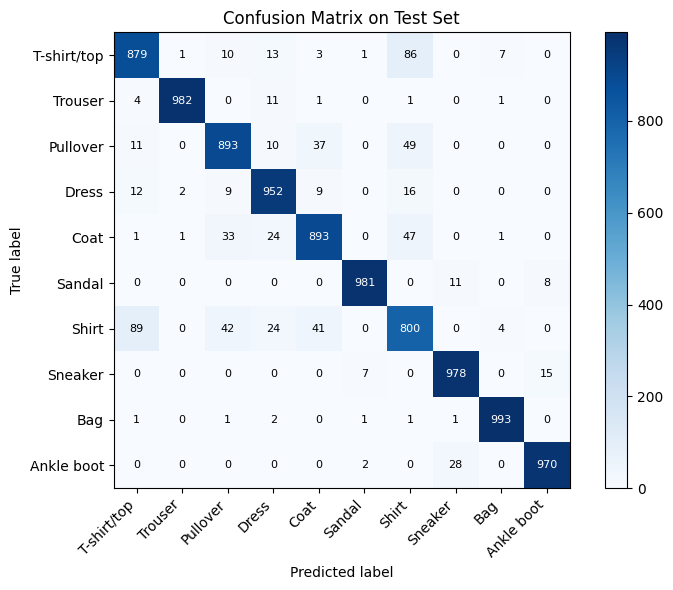

,错分数,真实类别,预测类别
0,89,Shirt,T-shirt/top
1,86,T-shirt/top,Shirt
2,49,Pullover,Shirt
3,47,Coat,Shirt
4,42,Shirt,Pullover


In [19]:
from sklearn.metrics import confusion_matrix

# 收集测试集上的全部预测结果，后续用于混淆矩阵和错分样本展示
final_result["model"].eval()
all_images, all_labels, all_preds = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = final_result["model"](images.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_preds.append(preds)

test_images = torch.cat(all_images)
test_labels = torch.cat(all_labels)
test_preds = torch.cat(all_preds)

# 绘制混淆矩阵，并列出最常见的错分对
cm = confusion_matrix(test_labels.numpy(), test_preds.numpy())

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix on Test Set")
fig.colorbar(im, ax=ax)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() * 0.5 else "black"
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], class_names[i], class_names[j]))

pairs.sort(reverse=True)
error_summary = pd.DataFrame(pairs[:5], columns=["错分数", "真实类别", "预测类别"])
display(error_summary)


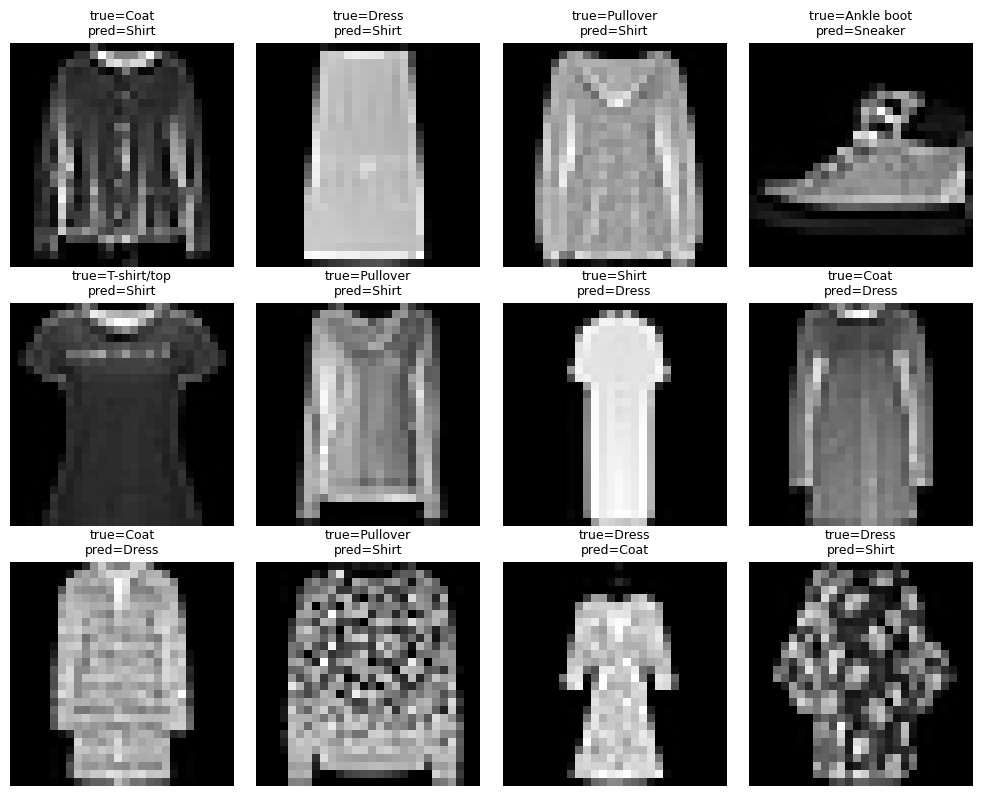

In [20]:
# 展示一部分错分样本，便于直观看出容易混淆的类别
error_index = torch.nonzero(test_labels != test_preds).squeeze(1)[:12]
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, idx in zip(axes.flat, error_index):
    image = test_images[idx] * std + mean
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"true={class_names[test_labels[idx]]}\npred={class_names[test_preds[idx]]}", fontsize=9)
    ax.axis("off")

for ax in axes.flat[len(error_index):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "misclassified_examples.png", dpi=300, bbox_inches="tight")
plt.show()
